In [11]:
# setup
import sys
import os

sys.path.append(os.path.abspath(".."))

# ICVul
import pandas as pd

df_vuln = pd.read_csv('../data/intermediate/churn_icvul.csv')

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
print(f"Total commits: {len(df_vuln)}")
# df_vuln.groupby('commit_role')[metrics].agg(['median', 'mean', 'count']).round(2)

import json

with open('../data/raw/tool_assisted_manual_dataset.json', 'r') as f:
    tosem = json.load(f)

total_vfc = len(set(commit for entry in tosem for commit in entry['fixing']))
total_vic = len(set(entry['introducing'] for entry in tosem if entry.get('introducing')))
total_cves = len(set(entry['cve'] for entry in tosem))
total_projects = len(set(entry['repository'] for entry in tosem))

print(f"Total unique VFCs: {total_vfc}")
print(f"Total unique VICs: {total_vic}")
print(f"Total unique CVEs: {total_cves}")
print(f"Total unique projects: {total_projects}")

Total commits: 13003
Total unique VFCs: 187
Total unique VICs: 95
Total unique CVEs: 100
Total unique projects: 71


In [12]:
# KFC (Linux)
import pandas as pd

df_bug = pd.read_csv('../data/intermediate/churn_linux.csv')

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

In [13]:
# TOSEM
import pandas as pd

df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem.csv')

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

In [14]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache.csv')

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

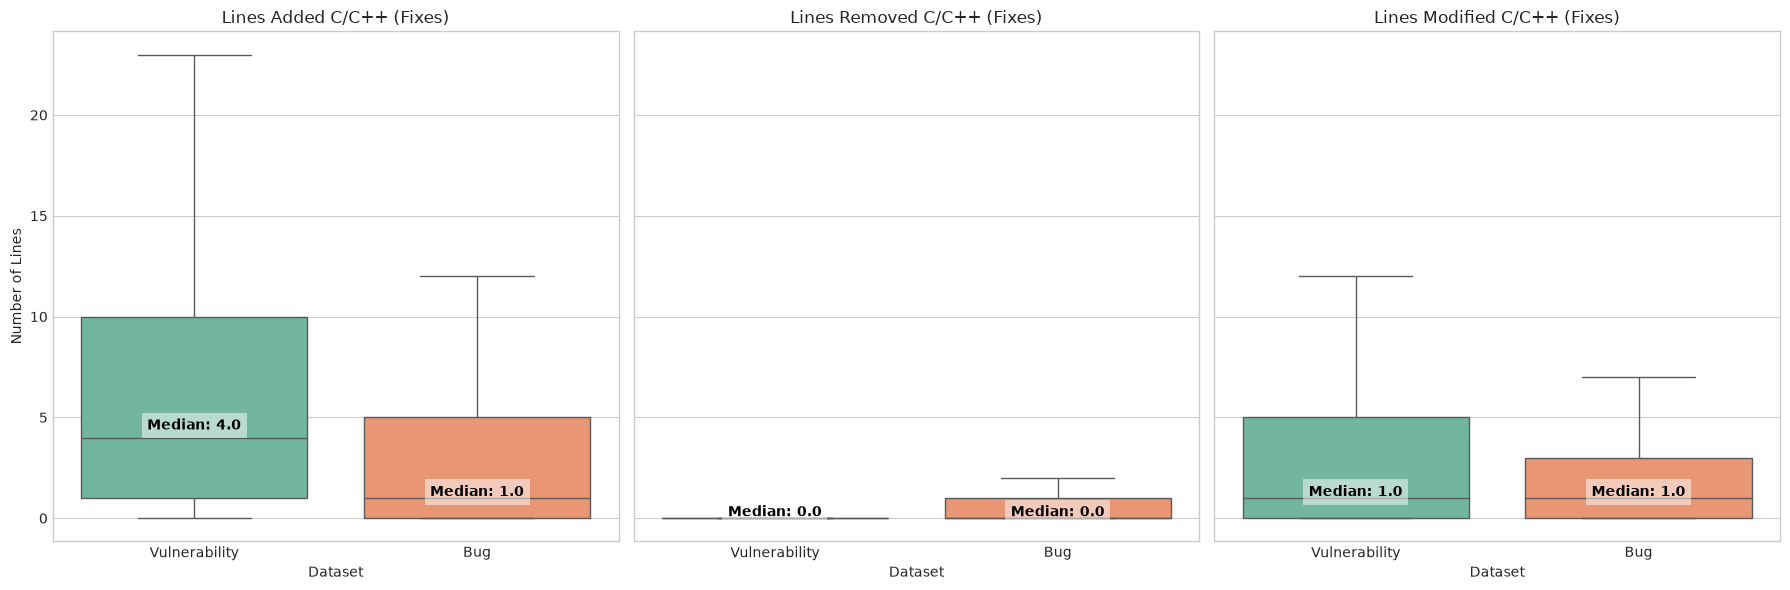


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 2.71e-196    |   0.266 (small     ) | *
Lines Removed      | 9.77e-13     |  -0.051 (negligible) | *
Lines Modified     | 5.87e-17     |   0.075 (negligible) | *


          Lines Added          Lines Removed          Lines Modified         
Dataset Vulnerability      Bug Vulnerability      Bug  Vulnerability      Bug
n              4230.0  63896.0        4230.0  63896.0         4230.0  63896.0
Median            4.0      1.0           0.0      0.0            1.0      1.0
Q1                1.0      0.0           0.0      0.0            0.0      0.0
Q3               10.0      5.0           0.0      1.0            5.0      3.0
Minimum           0.0      0.0           0.0      0.0            0.0      0.0
Maximum         986.0   1163.0       

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Fixes)', 'Lines Removed C/C++ (Fixes)', 'Lines Modified C/C++ (Fixes)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

from utils.stats import run_stats, descriptive_stats_table

run_stats(df_fixing)
table = descriptive_stats_table(df_fixing)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

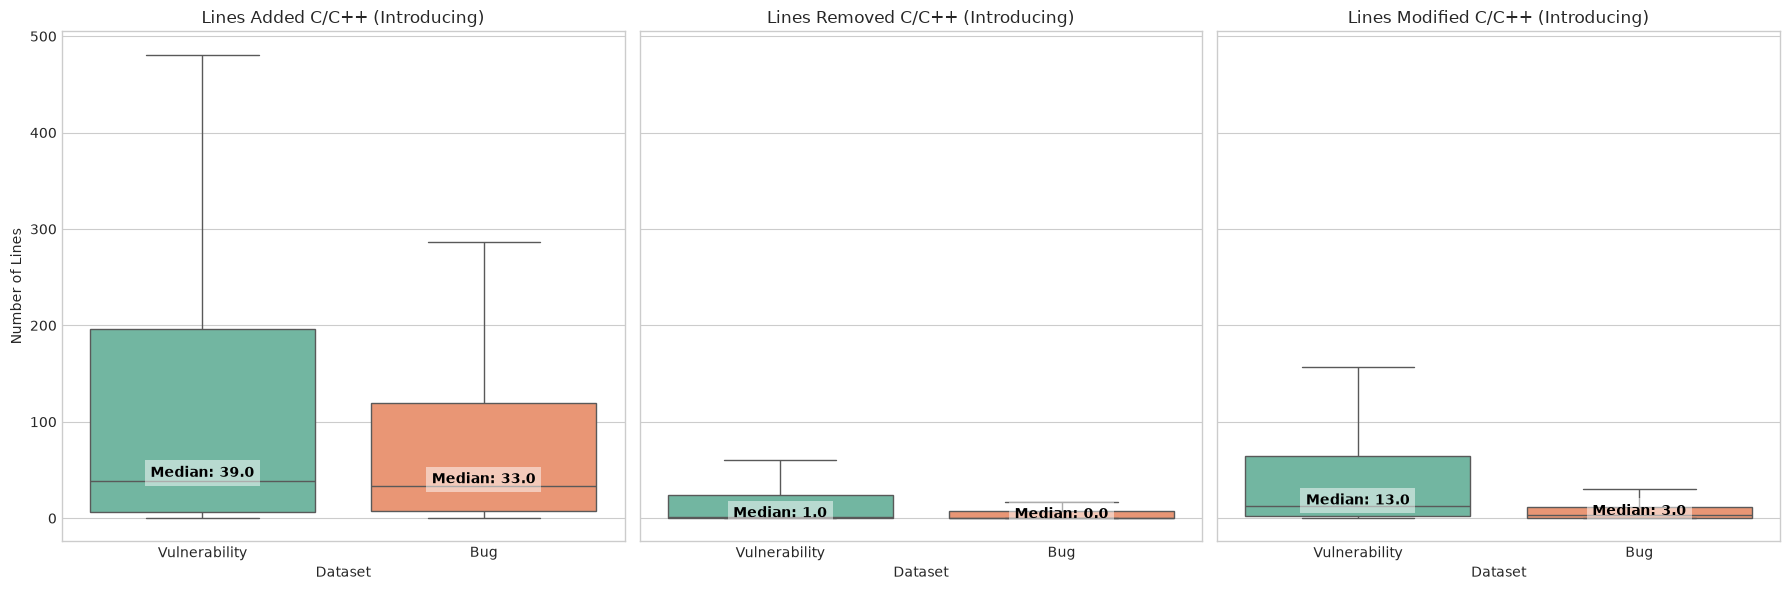


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 8.30e-15     |   0.053 (negligible) | *
Lines Removed      | 3.81e-159    |   0.166 (small     ) | *
Lines Modified     | 0.00e+00     |   0.351 (medium    ) | *


          Lines Added          Lines Removed          Lines Modified         
Dataset Vulnerability      Bug Vulnerability      Bug  Vulnerability      Bug
n              8512.0  48461.0        8512.0  48461.0         8512.0  48461.0
Median           39.0     33.0           1.0      0.0           13.0      3.0
Q1                6.0      7.0           0.0      0.0            2.0      0.0
Q3              196.0    119.0          24.0      7.0           64.0     12.0
Minimum           0.0      0.0           0.0      0.0            0.0      0.0
Maximum        9885.0   9892.0      2

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

df_introducing = pd.concat([
    df_vuln[(df_vuln['commit_role'] == 'VIC') & (df_vuln['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[(df_bug['commit_role'] == 'BIC') & (df_bug['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Introducing)', 'Lines Removed C/C++ (Introducing)', 'Lines Modified C/C++ (Introducing)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_introducing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_introducing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

run_stats(df_introducing)
table = descriptive_stats_table(df_introducing)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

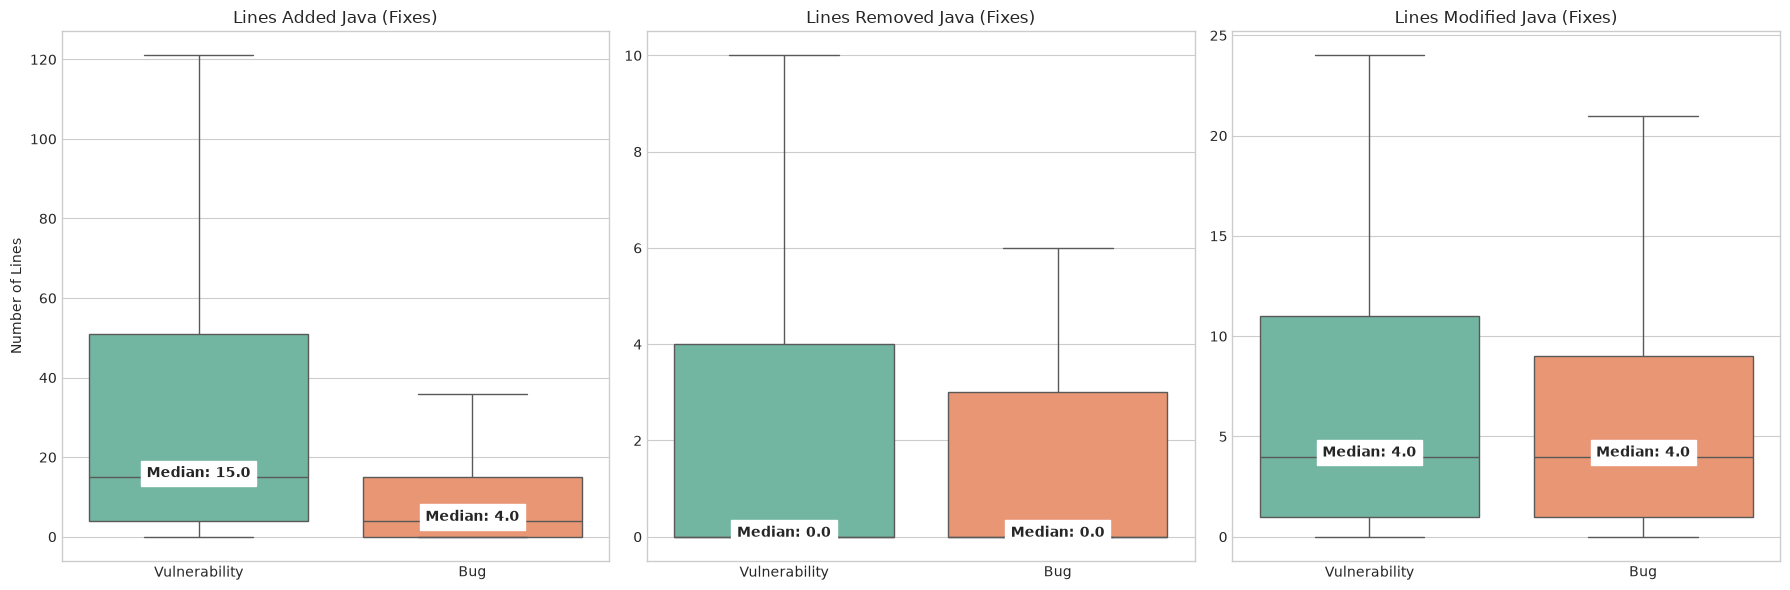


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 3.60e-10     |   0.373 (medium    ) | *
Lines Removed      | 0.35970      |   0.049 (negligible) | 
Lines Modified     | 0.99311      |  -0.001 (negligible) | 


          Lines Added        Lines Removed        Lines Modified       
Dataset Vulnerability    Bug Vulnerability    Bug  Vulnerability    Bug
n               177.0  198.0         177.0  198.0          177.0  198.0
Median           15.0    4.0           0.0    0.0            4.0    4.0
Q1                4.0    0.0           0.0    0.0            1.0    1.0
Q3               51.0   15.0           4.0    3.0           11.0    9.0
Minimum           0.0    0.0           0.0    0.0            0.0    0.0
Maximum        1688.0  807.0        1631.0  523.0          199.0  294.0


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Fixes)', 'Lines Removed Java (Fixes)', 'Lines Modified Java (Fixes)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp)
table = descriptive_stats_table(df_java_comp)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

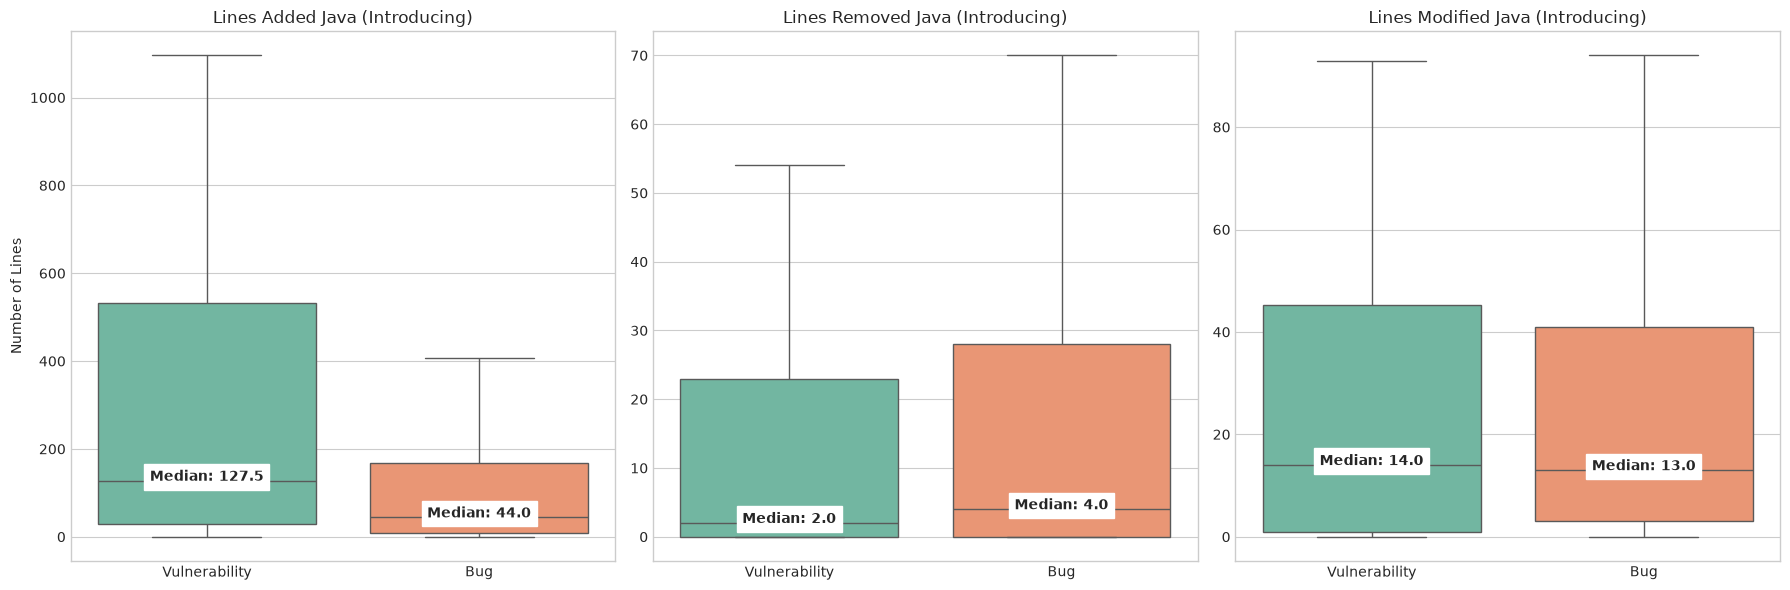


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 2.89e-05     |   0.300 (small     ) | *
Lines Removed      | 0.51409      |  -0.045 (negligible) | 
Lines Modified     | 0.32216      |  -0.071 (negligible) | 


          Lines Added         Lines Removed         Lines Modified        
Dataset Vulnerability     Bug Vulnerability     Bug  Vulnerability     Bug
n                84.0   285.0          84.0   285.0           84.0   285.0
Median          127.5    44.0           2.0     4.0           14.0    13.0
Q1               28.0     8.0           0.0     0.0            1.0     3.0
Q3              532.5   168.0          23.0    28.0           45.2    41.0
Minimum           0.0     0.0           0.0     0.0            0.0     0.0
Maximum        9075.0  7090.0       55243.0  2562.0         

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixses
df_v = df_java_vic_only.copy()
df_v = df_v[df_v['lines_added'] < 10000]
df_b = df_java_bic_only.copy()
df_b = df_b[df_b['lines_added'] < 10000] # this dataset doesn't have any commits with > 10k

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp_i = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Introducing)', 'Lines Removed Java (Introducing)', 'Lines Modified Java (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp_i, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp_i.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp_i)
table = descriptive_stats_table(df_java_comp_i)
latex = table.to_latex(
    float_format="%.1f",
    multicolumn=True,
    multicolumn_format='c',
    escape=False
)
print("\n")
print(table)

In [19]:
# usage — adjust column name if it's not literally "Language" in df_fixing
# data = compute_candlestick_stats(df_fixing, group_cols=("Language", "Dataset"))

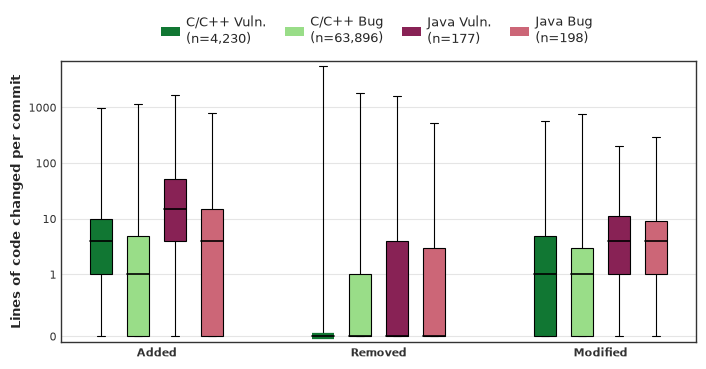

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Set global publication styling
plt.style.use(['seaborn-v0_8-whitegrid'])

# 1. Add Language labels to your C/C++ datasets
df_vuln['Language'] = 'C/C++'
df_bug['Language'] = 'C/C++'

# 2. Add Dataset and Language labels to Java datasets
df_java_vfc_only['Dataset'] = 'Vulnerability'
df_java_vfc_only['Language'] = 'Java'

df_java_bfc_only['Dataset'] = 'Bug'
df_java_bfc_only['Language'] = 'Java'

# 3. Concatenate all fixing datasets together
df_fixing_all = pd.concat([
    df_vuln[df_vuln['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset', 'Language']],
    df_bug[df_bug['Type'] == 'Fixing'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset', 'Language']],
    df_java_vfc_only[['lines_added', 'lines_removed', 'lines_modified', 'Dataset', 'Language']],
    df_java_bfc_only[['lines_added', 'lines_removed', 'lines_modified', 'Dataset', 'Language']]
])


def compute_candlestick_stats(df, group_cols=("Language", "Dataset")):
    """
    Mirrors descriptive_stats_table's logic, keeping the Language/Dataset split
    and returning a nested dict shaped for candlestick plotting.
    """
    metrics = [
        ("lines_added", "Added"),
        ("lines_removed", "Removed"),
        ("lines_modified", "Modified"),
    ]

    data = {}
    for group_key, sub in df.groupby(list(group_cols)):
        data[group_key] = {}
        for col, label in metrics:
            data[group_key][label] = {
                "median": sub[col].median(),
                "q1": sub[col].quantile(0.25),
                "q3": sub[col].quantile(0.75),
                "min": sub[col].min(),
                "max": sub[col].max(),
                "n": sub[col].count(),
            }
    return data


# Compute stats across fixing commits
data = compute_candlestick_stats(df_fixing_all, group_cols=("Language", "Dataset"))

METRICS = ["Added", "Removed", "Modified"]
GROUPS = [
    ("C/C++", "Vulnerability"),
    ("C/C++", "Bug"),
    ("Java", "Vulnerability"),
    ("Java", "Bug"),
]

# 2x2 Factorial Palette (Hue = Language, Luminance = Dataset Type)
COLOR_MAP = {
    ("C/C++", "Vulnerability"): "#117733",  # Deep Steel Blue
    ("C/C++", "Bug"):           "#99DD88",  # Light Steel Blue
    ("Java", "Vulnerability"):  "#882255",  # Dark Terracotta
    ("Java", "Bug"):            "#CC6677",  # Light Amber/Peach
}


def draw_candle(ax, x, stats, color, width=0.6, y_floor=0.5):
    q1 = stats["q1"]
    q3 = stats["q3"]
    med = stats["median"]
    lo = stats["min"]
    hi = stats["max"]
    
    cap_width = width * 0.35

    ax.plot(
        [x - cap_width / 2, x + cap_width / 2],
        [lo, lo],
        color="black",
        linewidth=0.8,
        zorder=2
    )

    ax.plot(
        [x - cap_width / 2, x + cap_width / 2],
        [hi, hi],
        color="black",
        linewidth=0.8,
        zorder=2
    )

    ax.plot([x, x], [lo, hi], color="black", linewidth=0.8, zorder=1)
    if q3 == q1:
        ax.plot(
            [x - width / 2, x + width / 2],
            [q1, q1],
            color=color,
            linewidth=4.5,
            solid_capstyle="butt",
            zorder=3,
        )
    else:
        ax.add_patch(
            plt.Rectangle(
                (x - width / 2, q1),
                width,
                q3 - q1,
                facecolor=color,
                edgecolor="black",
                linewidth=0.8,
                zorder=2,
            )
        )
    ax.plot(
        [x - width / 2, x + width / 2],
        [med, med],
        color="black",
        linewidth=1.2,
        zorder=4
    )


fig, ax = plt.subplots(figsize=(7.16, 3.8))

ax.axhline(0, color="0.65", linewidth=0.7, zorder=0)

group_width = len(GROUPS) + 2
xticks, xticklabels = [], []
all_max_vals = []

for mi, metric in enumerate(METRICS):
    base_x = mi * group_width
    for gi, group in enumerate(GROUPS):
        x = base_x + gi
        color = COLOR_MAP[group]
        stats = data[group][metric]
        draw_candle(ax, x, stats, color)
        all_max_vals.append(stats["max"])
    xticks.append(base_x + (len(GROUPS) - 1) / 2)
    xticklabels.append(metric)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=9, fontweight="bold")
ax.set_yscale("symlog", linthresh=1, linscale=1)
ax.set_ylim(bottom=-0.1, top=max(all_max_vals) * 1.2)
ax.set_ylabel("Lines of code changed per commit", fontsize=9, fontweight="bold")
ax.spines["bottom"].set_visible(False)
ax.spines[["top", "right"]].set_visible(False)

# Ensure grid sits behind candles
ax.set_axisbelow(True)
ax.grid(axis="y", which="major", color="0.85", linewidth=0.6)
ax.grid(axis="x", visible=False)

# 4-color legend matching each dataset group explicitly
legend_handles = [
    mpatches.Patch(
        facecolor=COLOR_MAP[("C/C++", "Vulnerability")],
        label=f"C/C++ Vuln. \n(n={data[('C/C++', 'Vulnerability')]['Added']['n']:,})",
    ),
    mpatches.Patch(
        facecolor=COLOR_MAP[("C/C++", "Bug")],
        label=f"C/C++ Bug \n(n={data[('C/C++', 'Bug')]['Added']['n']:,})"
    ),
    mpatches.Patch(
        facecolor=COLOR_MAP[("Java", "Vulnerability")],
        label=f"Java Vuln. \n(n={data[('Java', 'Vulnerability')]['Added']['n']:,})"
    ),
    mpatches.Patch(
        facecolor=COLOR_MAP[("Java", "Bug")],
        label=f"Java Bug \n(n={data[('Java', 'Bug')]['Added']['n']:,})"
    ),
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    frameon=False,
    ncol=4,
    columnspacing=1.2,
    handlelength=1.5,
    handletextpad=0.5,
    fontsize=9
)

from matplotlib.ticker import FuncFormatter

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: "" if y < 0 else f"{y:g}")
)

from utils.plot import style_axis

style_axis(ax)
plt.tight_layout()
plt.savefig("candle_stick_stats.pdf")
plt.show()